In [1]:
#modules to be imported
import numpy as np 
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve,roc_auc_score

In [2]:
df=pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

In [3]:
df.head(10)

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1
5,23107.txt,https://www.globalreporting.org,30,www.globalreporting.org,23,0,org,100.0,1.000000,0.079963,...,0,0,1,35,1,11,86,0,14,1
6,23034.txt,https://www.saffronart.com,25,www.saffronart.com,18,0,com,100.0,1.000000,0.522907,...,0,0,1,32,4,14,44,2,17,1
7,696732.txt,https://www.nerdscandy.com,25,www.nerdscandy.com,18,0,com,100.0,1.000000,0.522907,...,0,0,1,24,2,22,36,0,15,1
8,739255.txt,https://www.hyderabadonline.in,29,www.hyderabadonline.in,22,0,in,100.0,1.000000,0.005084,...,0,0,1,71,4,9,40,1,317,1
9,14486.txt,https://www.aap.org,18,www.aap.org,11,0,org,100.0,1.000000,0.079963,...,0,0,1,10,1,12,173,6,65,1


In [4]:
df.tail(10)

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
235785,429092.txt,https://www.virginiakraljevic.com,32,www.virginiakraljevic.com,25,0,com,100.000000,1.000000,0.522907,...,1,0,1,4,9,12,17,1,1,1
235786,406164.txt,https://www.chilconference.org,29,www.chilconference.org,22,0,org,100.000000,1.000000,0.079963,...,0,0,1,2,7,15,30,7,3,1
235787,424795.txt,https://www.indirekter-freistoss.de,34,www.indirekter-freistoss.de,27,0,de,100.000000,0.550000,0.032650,...,0,0,0,3,6,12,320,0,348,1
235788,632917.txt,https://www.karibpan.com,23,www.karibpan.com,16,0,com,100.000000,1.000000,0.522907,...,1,0,1,21,3,22,31,0,8,1
235789,179093.txt,https://www.life-in-ecuador.com,30,www.life-in-ecuador.com,23,0,com,100.000000,0.533333,0.522907,...,0,0,1,43,1,16,42,0,44,1
235790,660997.txt,https://www.skincareliving.com,29,www.skincareliving.com,22,0,com,100.000000,1.000000,0.522907,...,1,0,1,51,7,21,187,2,191,1
235791,77185.txt,https://www.winchester.gov.uk,28,www.winchester.gov.uk,21,0,uk,100.000000,0.785714,0.028555,...,1,0,0,50,1,7,88,0,31,1
235792,622132.txt,https://www.nononsensedesign.be,30,www.nononsensedesign.be,23,0,be,100.000000,1.000000,0.003319,...,0,0,1,27,10,30,58,2,67,1
235793,7503962.txt,https://patient-cell-40f5.updatedlogmylogin.wo...,55,patient-cell-40f5.updatedlogmylogin.workers.dev,47,0,dev,28.157537,0.465116,0.000961,...,0,0,0,0,0,3,0,0,0,0
235794,384822.txt,https://www.alternativefinland.com,33,www.alternativefinland.com,26,0,com,100.000000,1.000000,0.522907,...,0,0,1,21,6,18,256,0,261,1


In [1]:
df.describe(include="all")

NameError: name 'df' is not defined

In [5]:
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

In [7]:
df.isnull()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
235791,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
235792,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
235793,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.notnull()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
235791,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
235792,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
235793,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


In [9]:
df.dtypes

FILENAME                       object
URL                            object
URLLength                       int64
Domain                         object
DomainLength                    int64
IsDomainIP                      int64
TLD                            object
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                         int64
LineOfCode  

In [10]:
df.columns

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

In [11]:
df.shape

(235795, 56)

In [12]:
df['label'].value_counts()

label
1    134850
0    100945
Name: count, dtype: int64

134850 legitimate URLs and 100945 phishing URLs


histogram graph

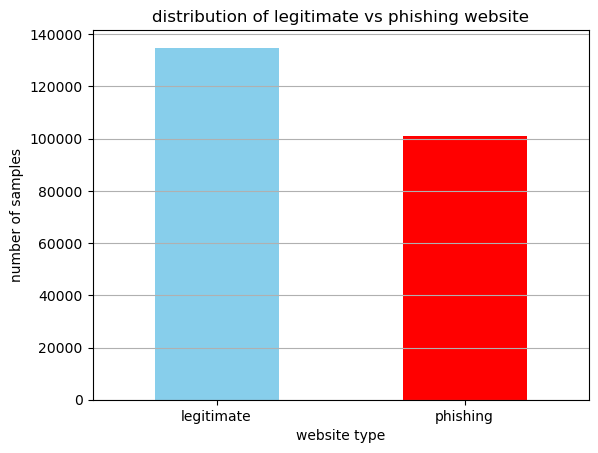

In [15]:
%matplotlib inline
#import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar',color=['skyblue','red'])
plt.xticks([0,1],['legitimate','phishing'], rotation=0)
plt.title('distribution of legitimate vs phishing website')
plt.xlabel('website type')
plt.ylabel('number of samples')
plt.grid(axis='y')
plt.show()

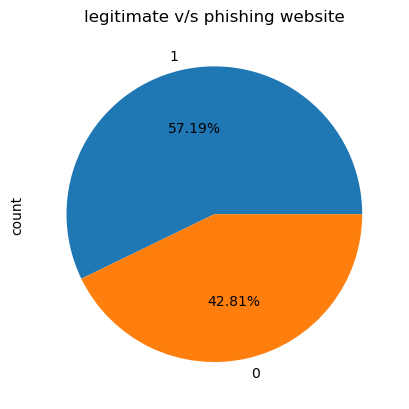

In [16]:
df['label'].value_counts().plot(kind='pie',autopct='%1.2f%%')
plt.title("legitimate v/s phishing website")
plt.show()


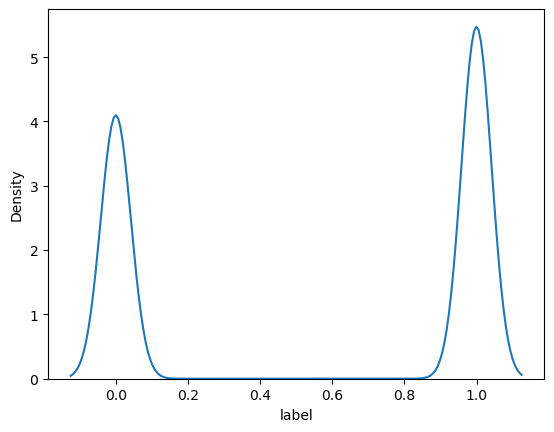

In [17]:
sns.kdeplot(df['label'])
plt.show()

plt.figure(figsize=(15,15))
sns.heatmap(df.corr(), annot=True)
plt.show()

**handling outliers**

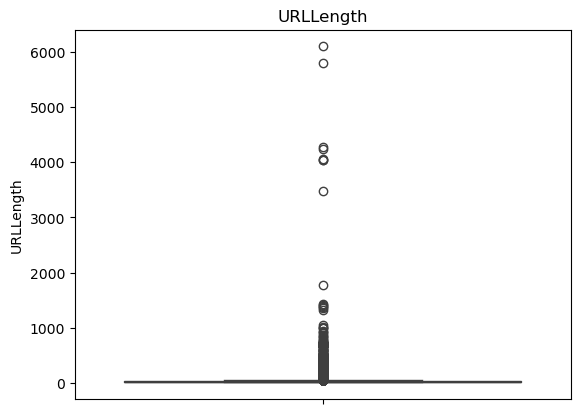

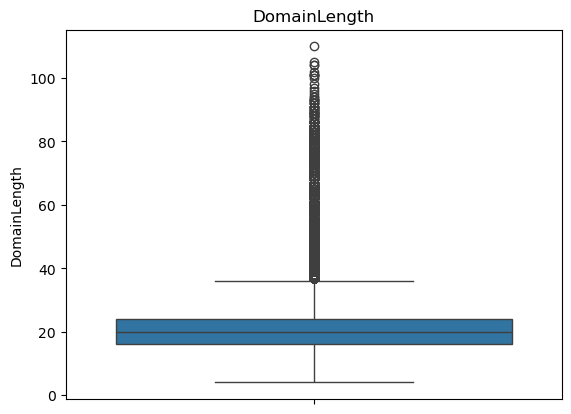

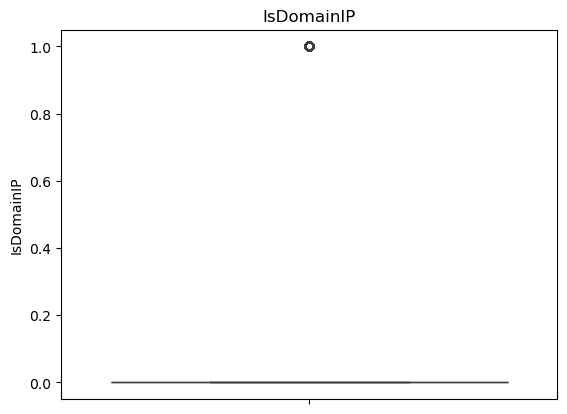

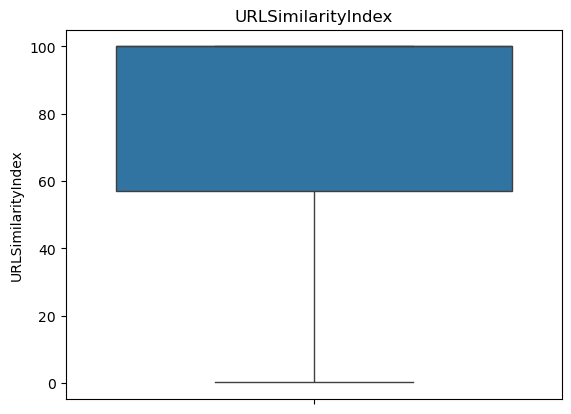

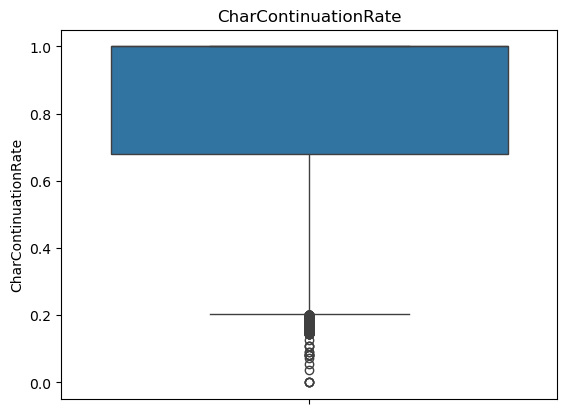

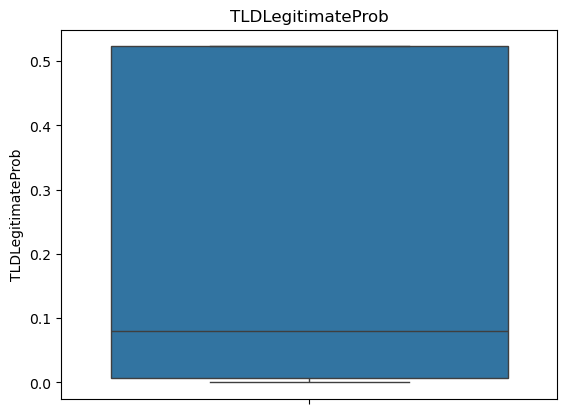

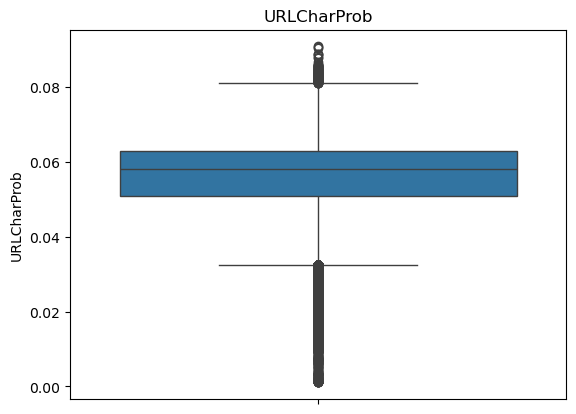

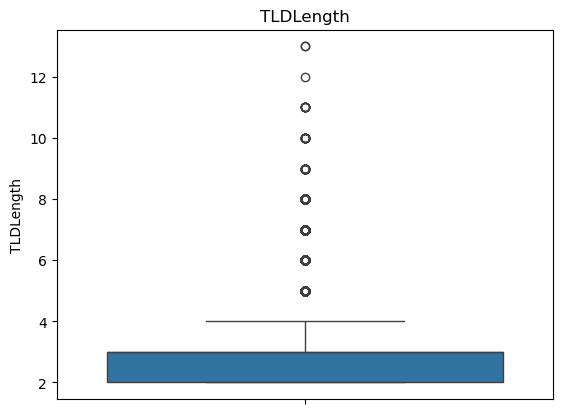

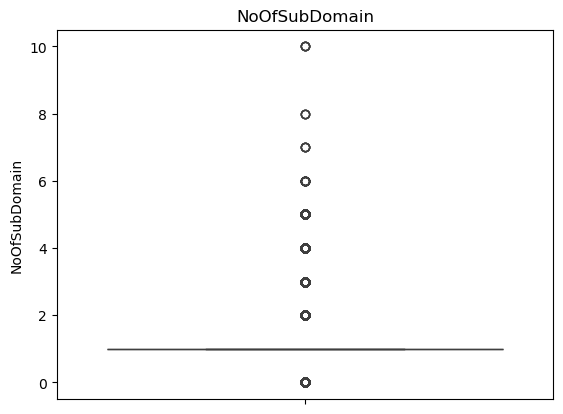

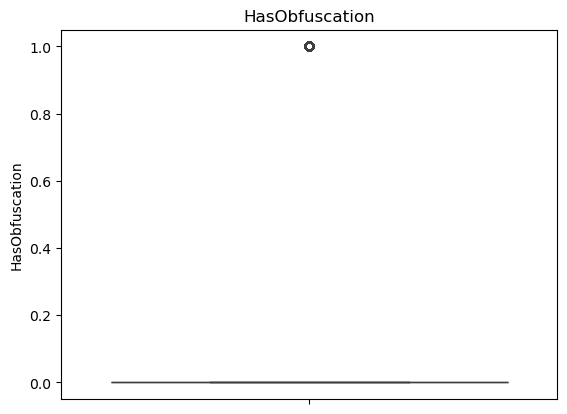

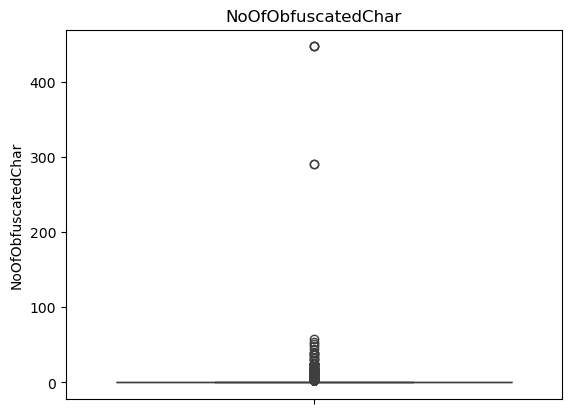

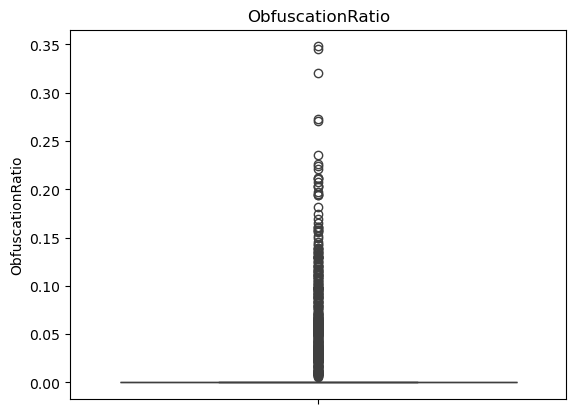

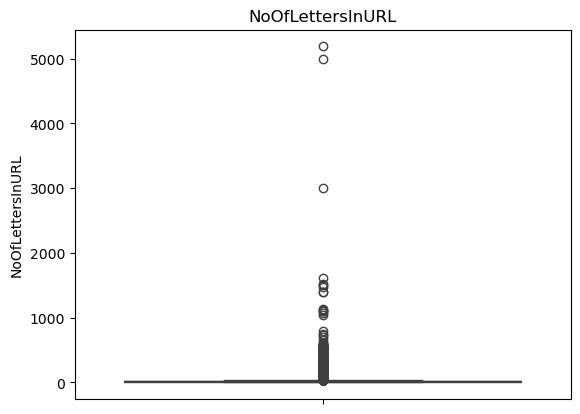

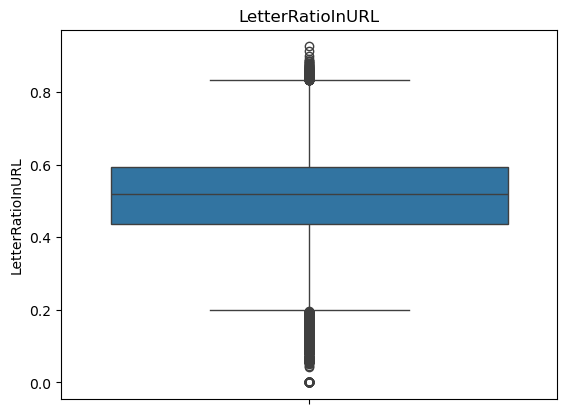

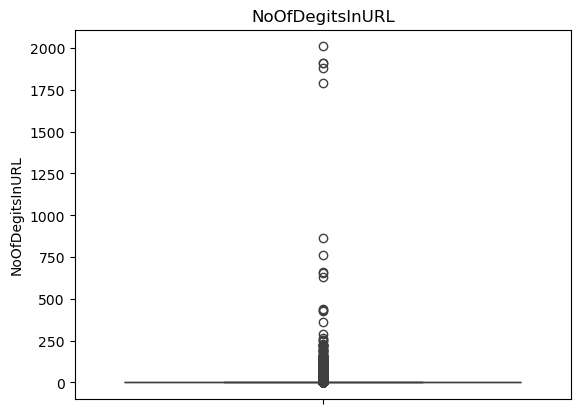

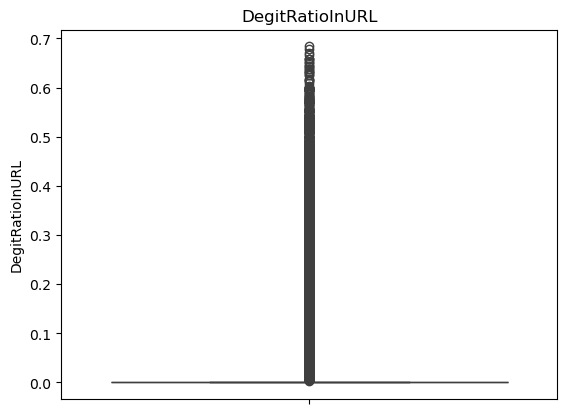

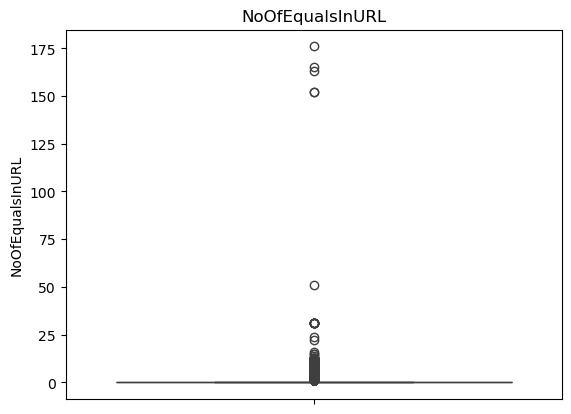

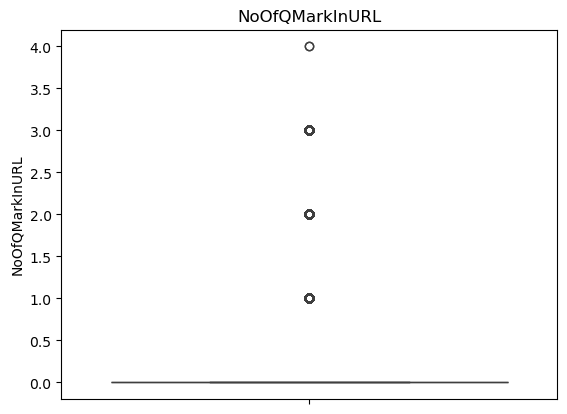

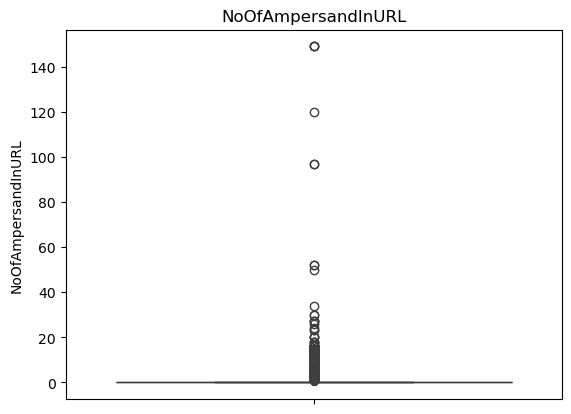

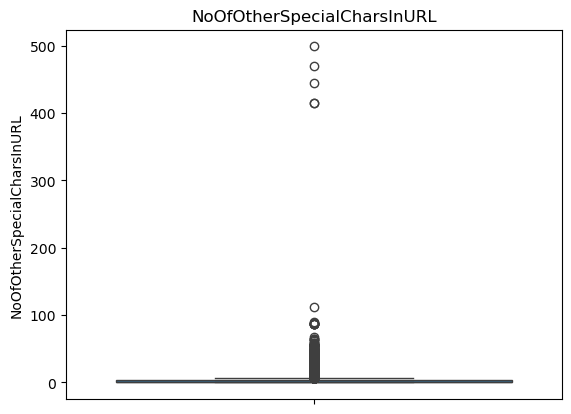

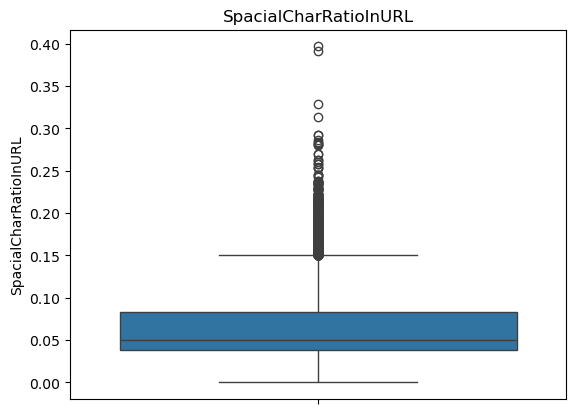

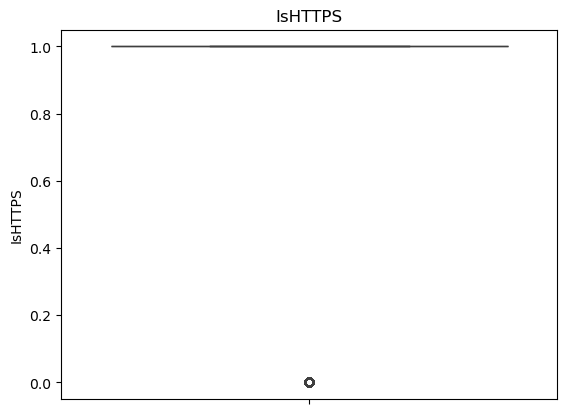

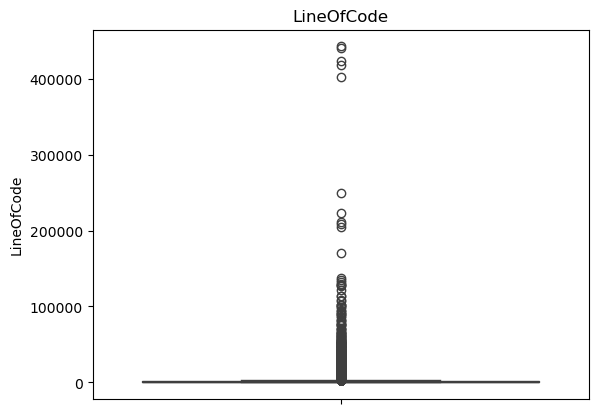

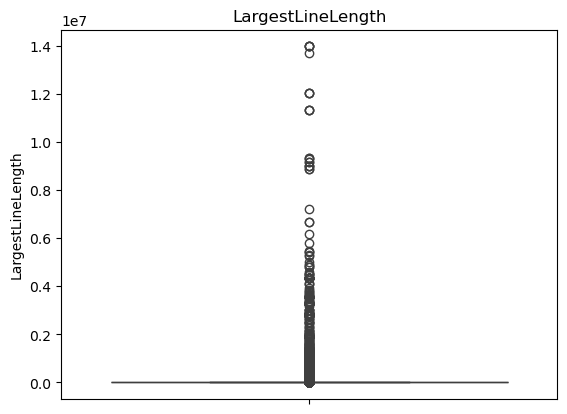

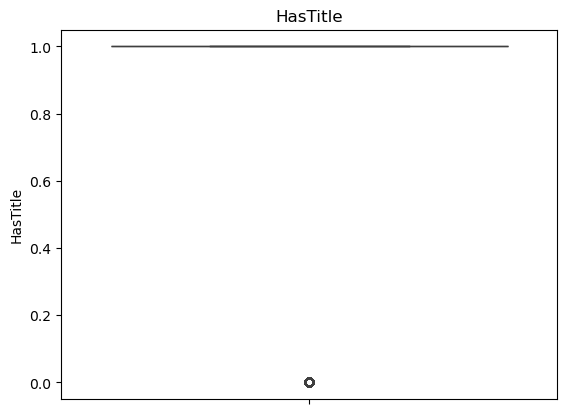

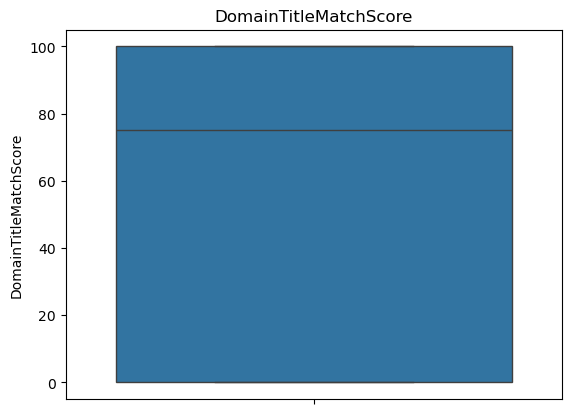

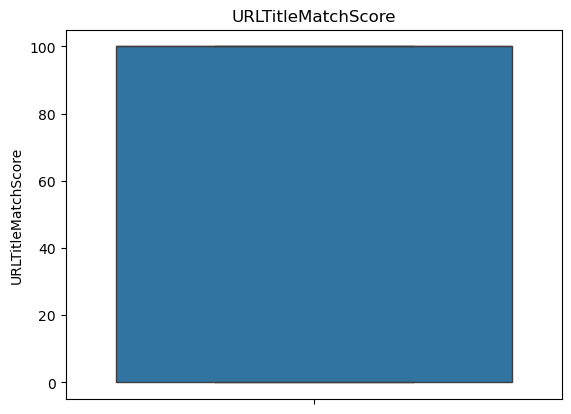

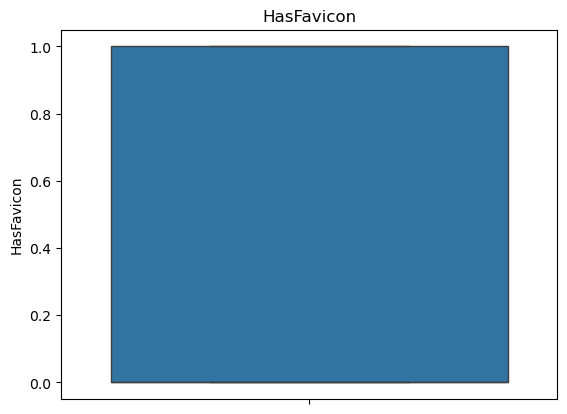

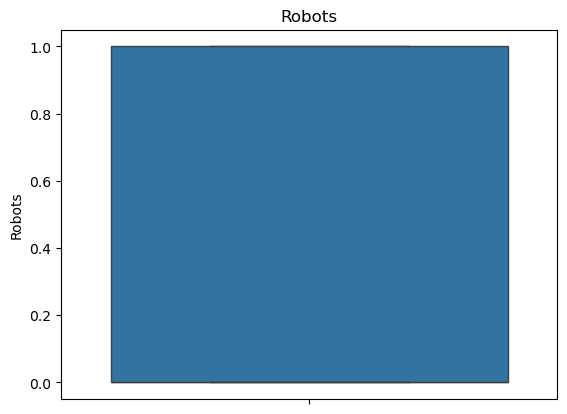

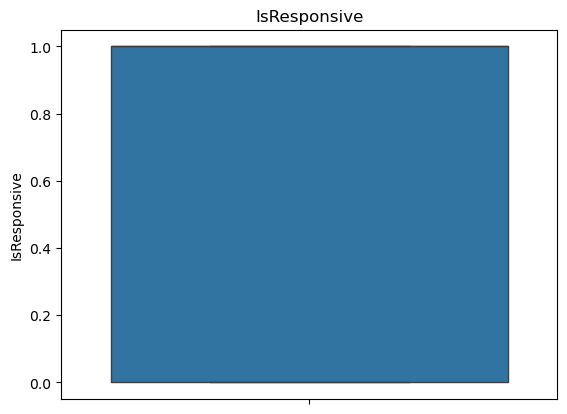

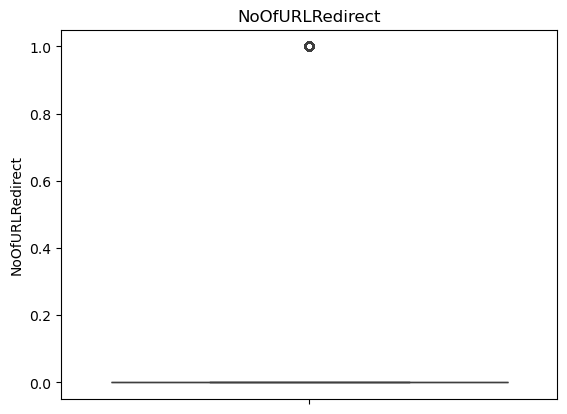

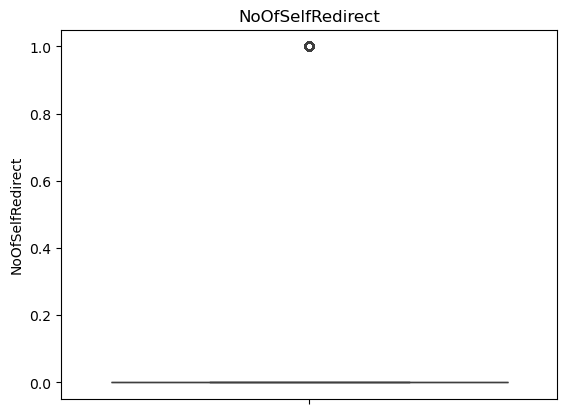

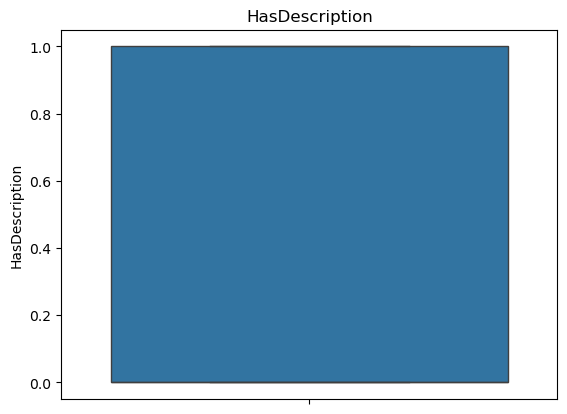

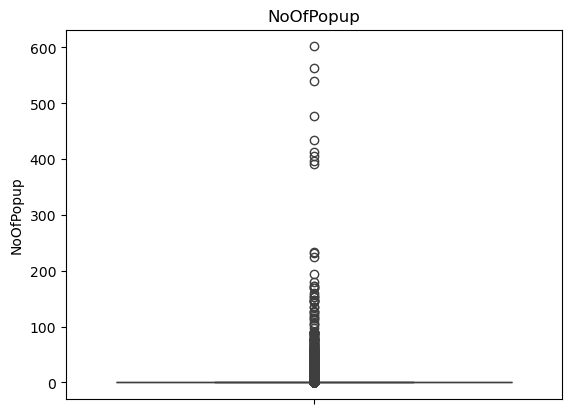

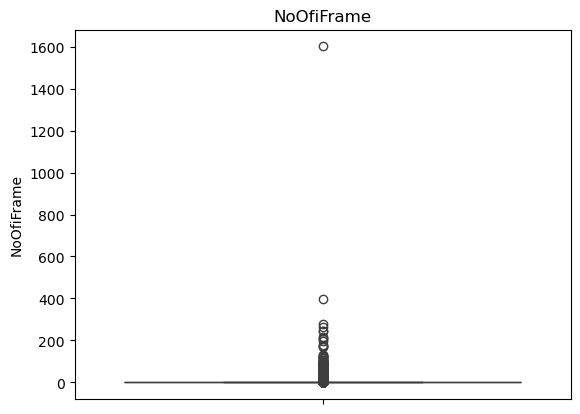

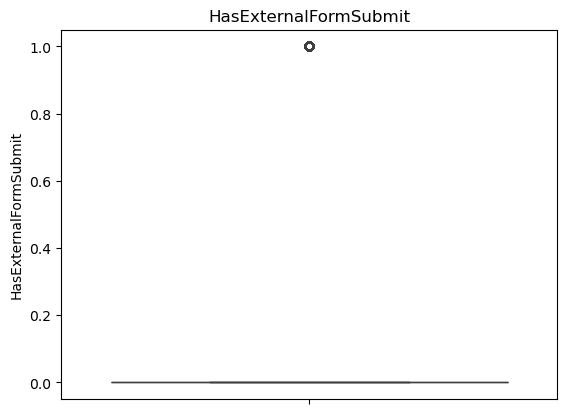

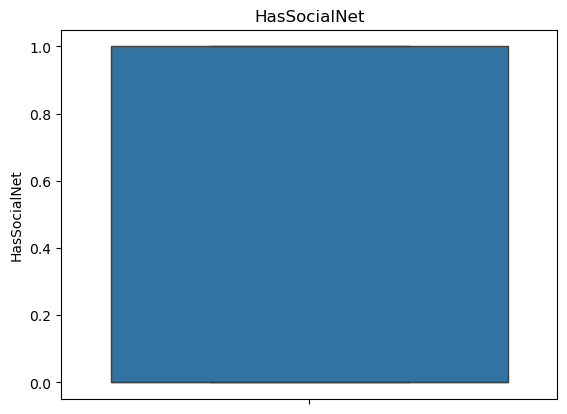

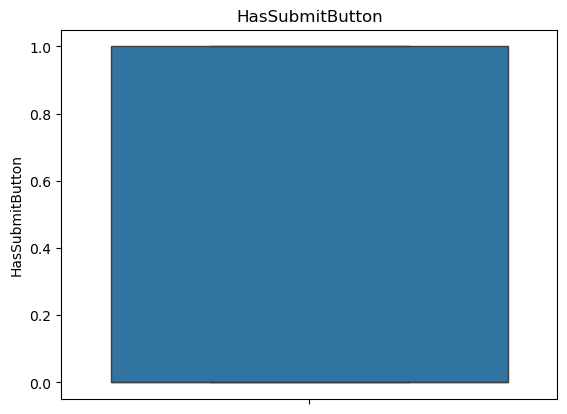

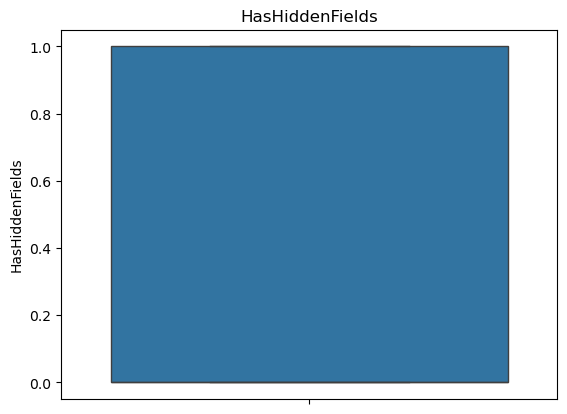

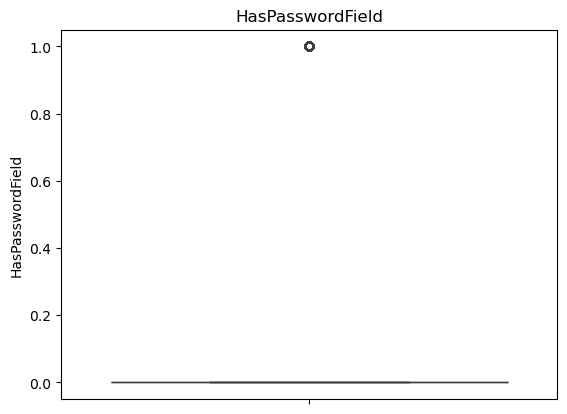

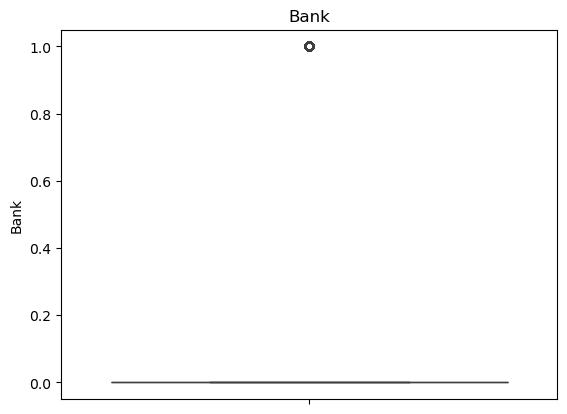

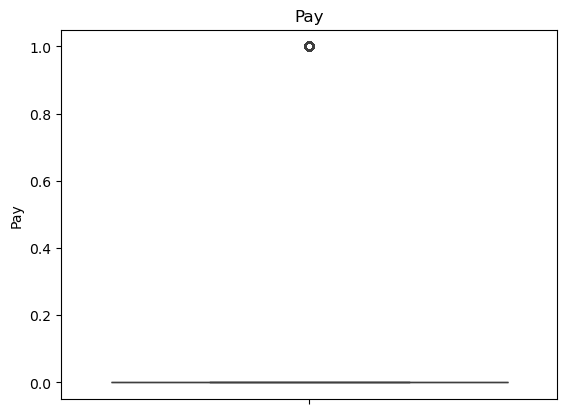

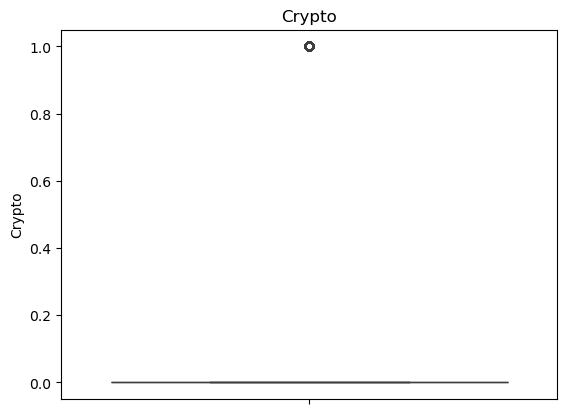

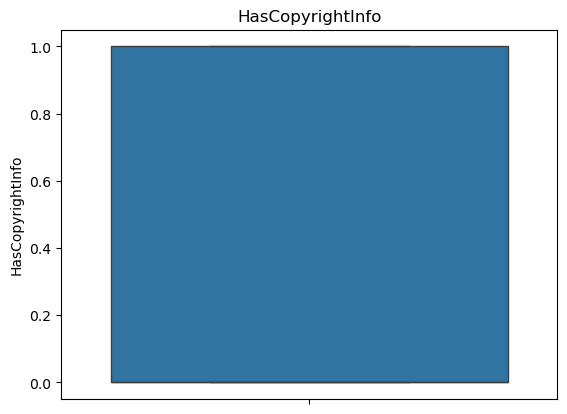

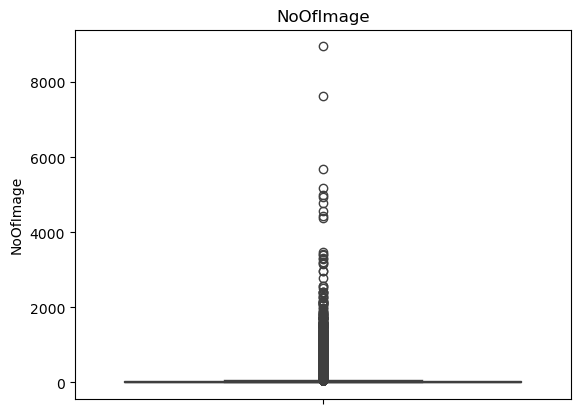

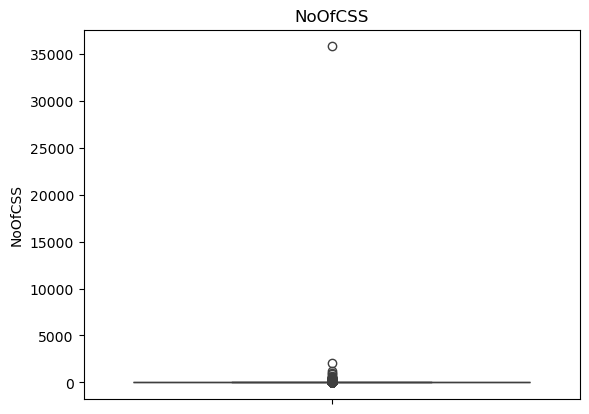

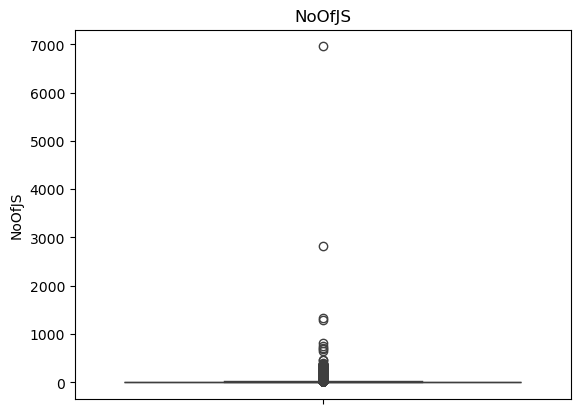

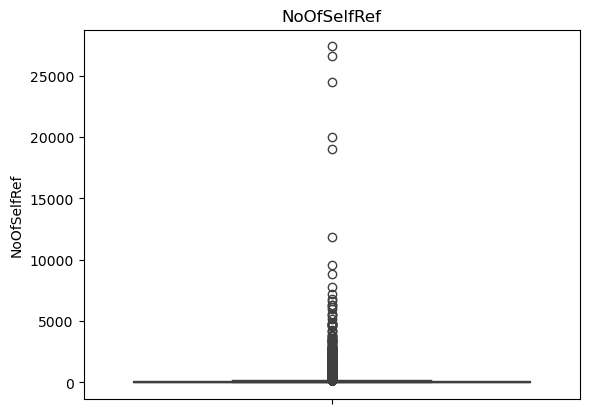

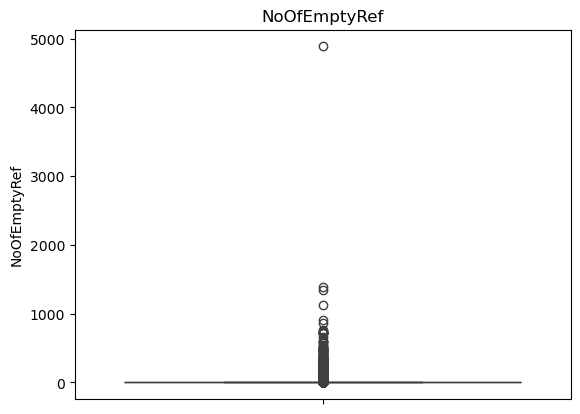

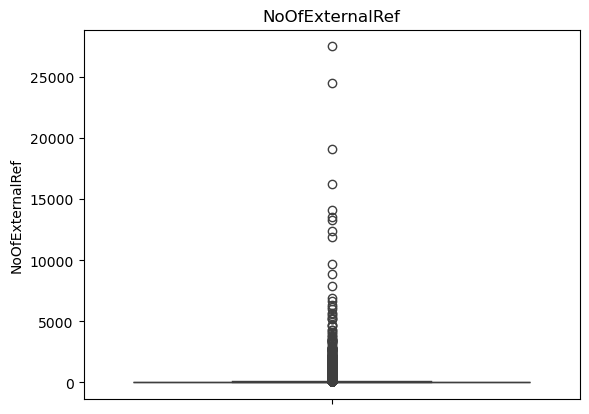

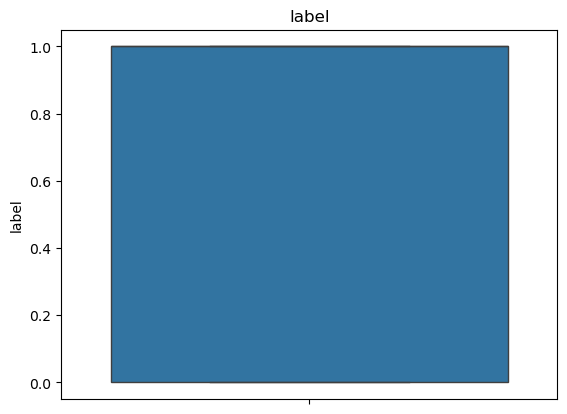

In [20]:
for i in df.columns:
    if type(df[i][0])!=str:
        sns.boxplot(df[i])
        plt.title(i)
        plt.show()

**encoding**

In [22]:
df.columns

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

In [23]:
df=df.drop(['FILENAME','URL','Domain','Title'],axis=1)

In [24]:
df.columns

Index(['URLLength', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex',
       'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength',
       'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar',
       'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL',
       'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL',
       'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon',
       'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect',
       'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit',
       'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields',
       'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo',
       'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef',
       'NoOfExternalRef', 'label'],
      dtype='object')

In [25]:
df['TLD'].value_counts()

TLD
com      112554
org       18793
net        7097
app        6508
uk         6395
          ...  
47            1
sharp         1
faith         1
243           1
ne            1
Name: count, Length: 695, dtype: int64

In [26]:
result=df[df['TLD']=='100']
result

,URLLength,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
39604,32,14,1,100,27.920228,0.4,0.0,0.015141,3,2,...,0,0,0,0,0,0,0,0,0,0


In [27]:
tld_dummy=(pd.get_dummies(df['TLD'],sparse=True)).astype(int)
tld_dummy

,100,101,103,106,107,108,11,110,111,116,...,xyz,yachts,ye,yoga,youtube,yt,za,zm,zone,zw
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
235791,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
235792,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
235793,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
df=pd.concat([tld_dummy,df],axis=1)
df

,100,101,103,106,107,108,11,110,111,116,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,34,20,28,119,0,124,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,50,9,8,39,0,217,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,10,2,7,42,2,5,1
3,0,0,0,0,0,0,0,0,0,0,...,1,1,1,3,27,15,22,1,31,1
4,0,0,0,0,0,0,0,0,0,0,...,1,0,1,244,15,34,72,1,85,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,0,0,0,0,0,0,0,0,0,0,...,1,0,1,51,7,21,187,2,191,1
235791,0,0,0,0,0,0,0,0,0,0,...,1,0,0,50,1,7,88,0,31,1
235792,0,0,0,0,0,0,0,0,0,0,...,0,0,1,27,10,30,58,2,67,1
235793,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,3,0,0,0,0


In [29]:
df=df.drop(['TLD'],axis=1)
df.head(4)

,100,101,103,106,107,108,11,110,111,116,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,34,20,28,119,0,124,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,50,9,8,39,0,217,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,10,2,7,42,2,5,1
3,0,0,0,0,0,0,0,0,0,0,...,1,1,1,3,27,15,22,1,31,1


In [30]:
df.shape

(235795, 746)

***splitting dataset in 70 30***

In [32]:
X=df.iloc[:,:-1]
X


,100,101,103,106,107,108,11,110,111,116,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,1,34,20,28,119,0,124
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,50,9,8,39,0,217
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,10,2,7,42,2,5
3,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,3,27,15,22,1,31
4,0,0,0,0,0,0,0,0,0,0,...,1,1,0,1,244,15,34,72,1,85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,51,7,21,187,2,191
235791,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,50,1,7,88,0,31
235792,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,27,10,30,58,2,67
235793,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,3,0,0,0


In [33]:
y=df.iloc[:,-1]
y

0         1
1         1
2         1
3         1
4         1
         ..
235790    1
235791    1
235792    1
235793    0
235794    1
Name: label, Length: 235795, dtype: int64

In [34]:
#from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=56)

In [35]:
X_train

,100,101,103,106,107,108,11,110,111,116,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
111741,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
186628,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
76900,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,22,7,8,92,1,88
168305,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,7,4,4,97,1,61
67537,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173178,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,688,4,8,119,0,165
156907,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,17,13,22,1,0,119
134336,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,10,2,1,0,0,0
164239,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,147,1,8,197,1,70


In [36]:
X_test

,100,101,103,106,107,108,11,110,111,116,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
206479,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,9,0,3,82,0,4
72014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
74221,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
127903,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,57,11,16,17,0,43
103957,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103091,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,28,5,11,73,4,78
212149,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
5512,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,48,5,53,199,0,72
226237,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,28,2,6,49,5,56


In [37]:
y_train

111741    0
186628    0
76900     1
168305    1
67537     0
         ..
173178    1
156907    1
134336    0
164239    1
231908    0
Name: label, Length: 165056, dtype: int64

In [38]:
y_test

206479    1
72014     0
74221     0
127903    1
103957    0
         ..
103091    1
212149    0
5512      1
226237    1
175546    0
Name: label, Length: 70739, dtype: int64

***feature scaling***

In [40]:
#from sklearn.preprocessing import StandardScaler

sc=StandardScaler()
X_train[['URLSimilarityIndex','LineOfCode','LargestLineLength','DomainTitleMatchScore','URLTitleMatchScore','NoOfImage','NoOfCSS','NoOfSelfRef','NoOfExternalRef']]=sc.fit_transform(X_train[['URLSimilarityIndex','LineOfCode','LargestLineLength','DomainTitleMatchScore','URLTitleMatchScore','NoOfImage','NoOfCSS','NoOfSelfRef','NoOfExternalRef']])
X_train.head(4)

,100,101,103,106,107,108,11,110,111,116,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
111741,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,-0.324143,-0.470483,0,-0.371734,0,-0.292302
186628,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,-0.324143,-0.470483,0,-0.366029,0,-0.292302
76900,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,-0.051189,0.062142,8,0.153113,1,0.232103
168305,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,-0.237294,-0.166126,4,0.181637,1,0.069356


In [41]:
X_test[['URLSimilarityIndex','LineOfCode','LargestLineLength','DomainTitleMatchScore','URLTitleMatchScore','NoOfImage','NoOfCSS','NoOfSelfRef','NoOfExternalRef']]=sc.transform(X_test[['URLSimilarityIndex','LineOfCode','LargestLineLength','DomainTitleMatchScore','URLTitleMatchScore','NoOfImage','NoOfCSS','NoOfSelfRef','NoOfExternalRef']])
X_test.head(4)

,100,101,103,106,107,108,11,110,111,116,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
206479,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,-0.212480,-0.470483,3,0.096064,0,-0.274219
72014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,-0.324143,-0.470483,0,-0.366029,0,-0.292302
74221,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,-0.324143,-0.470483,0,-0.371734,1,-0.292302
127903,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0.383054,0.366500,16,-0.274751,0,-0.039141


***model selection and training***


**1. logistic regression**

#sklearn.model_selection.train_test_split and matplotlib.pyplot are already imported above
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import seaborn as sns
from sklearn.metrics import precision_recall_curve

In [45]:
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [46]:
#makes prediction
y_pred=model.predict(X_test)
y_proba=model.predict_proba(X_test)[:,1]

In [47]:
#accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print(f'accuracy: {accuracy:}')

accuracy: 0.9999151811589081


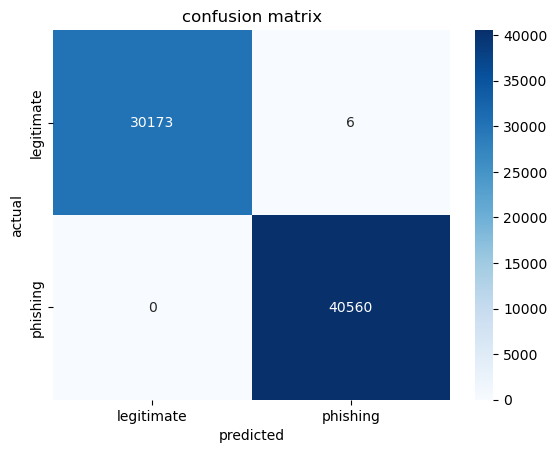

In [48]:
#confusion_matrix
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['legitimate','phishing'],yticklabels=['legitimate','phishing'])
plt.title('confusion matrix')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()

In [49]:
#classification report
report=classification_report(y_test,y_pred,target_names=['legitimate','phishing'])
print(report)

              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00     30179
    phishing       1.00      1.00      1.00     40560

    accuracy                           1.00     70739
   macro avg       1.00      1.00      1.00     70739
weighted avg       1.00      1.00      1.00     70739



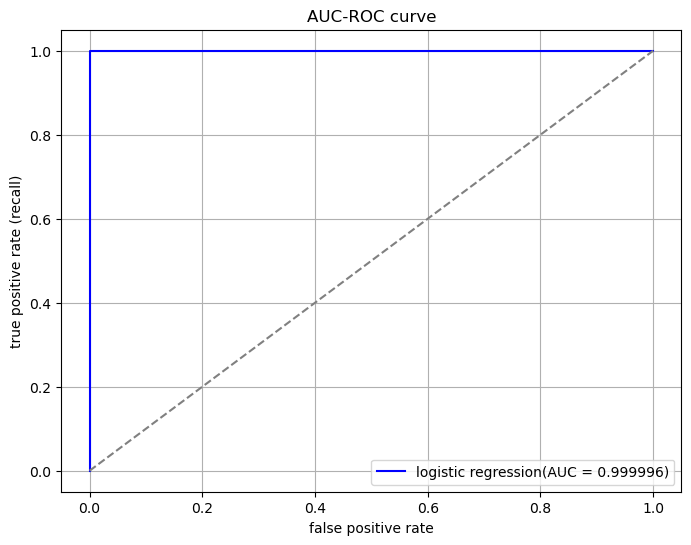

In [50]:
#AUC-ROC curve
#fpr=false positive rate, tpr=true positive rate
fpr,tpr,thresholds=roc_curve(y_test,y_proba)
auc=roc_auc_score(y_test,y_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='blue',label=f'logistic regression(AUC ={auc: f})')
plt.plot([0,1],[0,1],color='grey',linestyle='--')
plt.title('AUC-ROC curve')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate (recall)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#precision-recall curve

precision,recall,_=precision_recall_curve(y_test,y_proba)
plt.plot(recall,precision,color='blue')
plt.title('precision-recall-curve')
plt.xlabel('recall')
plt.ylabel('precision')
plt.grid(True)
plt.show()

**2. Random Forest**

from sklearn.ensemble import RandomForestClassifier

In [54]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=56)
rf_model.fit(X_train,y_train)

RandomForestClassifier(random_state=56)

In [55]:
y_pred_1=rf_model.predict(X_test)
y_proba_1=rf_model.predict_proba(X_test)[:,1]

In [56]:
accuracy_1=accuracy_score(y_test,y_pred_1)
print(f'accuracy:{accuracy_1:}')

accuracy:0.9999434541059388


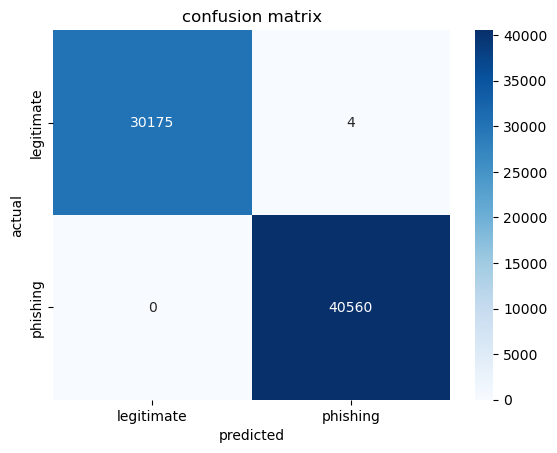

In [57]:
cm_1=confusion_matrix(y_test,y_pred_1)
sns.heatmap(cm_1,annot=True,fmt='d',cmap='Blues',xticklabels=['legitimate','phishing'],yticklabels=['legitimate','phishing'])
plt.title('confusion matrix')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()

In [58]:
#classification report
report_1=classification_report(y_test,y_pred_1,target_names=['legitimate','phishing'])
print(report_1)

              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00     30179
    phishing       1.00      1.00      1.00     40560

    accuracy                           1.00     70739
   macro avg       1.00      1.00      1.00     70739
weighted avg       1.00      1.00      1.00     70739



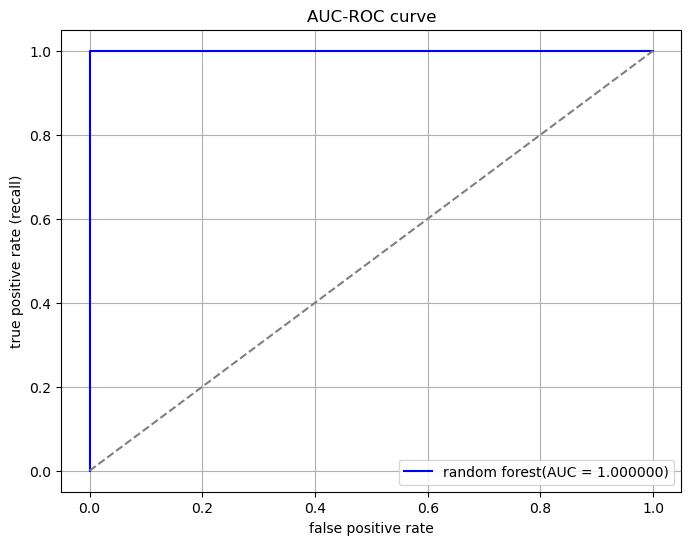

In [59]:
#AUC-ROC curve
#fpr=false positive rate, tpr=true positive rate
fpr_rf,tpr_rf,thresholds=roc_curve(y_test,y_proba_1)
auc=roc_auc_score(y_test,y_proba_1)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf,tpr_rf,color='blue',label=f'random forest(AUC ={auc: f})')
plt.plot([0,1],[0,1],color='grey',linestyle='--')
plt.title('AUC-ROC curve')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate (recall)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


#precision-recall curve
#from sklearn.metrics import precision_recall_curve
precision_1,recall_1,_=precision_recall_curve(y_test,y_proba_1)
plt.plot(recall_1,precision_1,color='blue')
plt.title('precision-recall-curve')
plt.xlabel('recall')
plt.ylabel('precision')
plt.grid(True)
plt.show()

In [61]:
import joblib
joblib.dump(rf_model, "fraud_model.pkl")
print("✅ Model saved as fraud_model.pkl")



✅ Model saved as fraud_model.pkl
